# Лабораторная работа №5  
# Мультимодальные LLM (LMM)

---

**Выполнил(а):** студент(ка) группы ______  
**ФИО:** _______________________________  
**Дата:** _______________________________

---

## 1. Цель работы

После выполнения этой лабораторной работы вы:
- Понять принципы работы мультимодальных моделей
- Изучить архитектуру LMM (Language Multimodal Models)
- Реализовывать Visual Question Answering (VQA)

---

## 2. Теоретические сведения

### 2.1. Мультимодальность в ИИ

**Мультимодальная модель** — модель, способная обрабатывать и связывать информацию из разных модальностей (текст, изображение, аудио, видео).

| Модальность | Примеры задач |
|-------------|---------------|
| Текст → Текст | Перевод, суммаризация, генерация |
| Изображение → Текст | Описание сцены, OCR, VQA |
| Текст → Изображение | Генерация по промпту |
| Изображение + Текст → Текст | Визуальный диалог, анализ |

### 2.2. Архитектура LMM

**LMM (Language Multimodal Model)** объединяет:

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│   Изображение   │ ──→ │  Vision Encoder │ ──→ │  Визуальные     │
│                 │     │   (ViT/CLIP)    │     │  эмбеддинги     │
└─────────────────┘     └─────────────────┘     │                 │
                                                │    Projection   │
┌─────────────────┐     ┌─────────────────┐     │    Layer        │
│     Текст       │ ──→ │  Text Tokenizer │ ──→ │                 │
│   (вопрос)      │     │                 │     │                 │
└─────────────────┘     └─────────────────┘     └────────┬────────┘
                                                         │
                                                         ▼
                                                ┌─────────────────┐
                                                │      LLM        │
                                                │  (Language Model)│
                                                └────────┬────────┘
                                                         │
                                                         ▼
                                                ┌─────────────────┐
                                                │   Текстовый     │
                                                │    ответ        │
                                                └─────────────────┘
```

**Компоненты:**
1. **Vision Encoder** — извлекает визуальные признаки (ViT, CLIP)
2. **Projection Layer** — преобразует визуальные эмбеддинги в пространство LLM
3. **LLM** — генерирует текст на основе визуального контекста

### 2.3. Qwen2-VL и Qwen2.5-VL — современные мультимодальные модели

**Qwen-VL** — серия мультимодальных моделей от Alibaba с отличной поддержкой русского языка.

| Версия | Размер | GPU память | Особенности |
|--------|--------|------------|-------------|
| Qwen2-VL-2B | 2B | ~4 GB | Компактная, быстрая |
| **Qwen2.5-VL-3B** | **3B** | **~6 GB** | **Улучшенное качество, OCR** |
| Qwen2.5-VL-7B | 7B | ~14 GB | Высокая точность |

**Преимущества Qwen2.5-VL:**
- ✅ **Поддержка русского языка** — обучена на мультиязычных данных
- ✅ **Эффективность** — 3B модель помещается в Colab (T4, 16GB)
- ✅ **Улучшенный OCR** — распознавание текста на изображениях
- ✅ **Гибкое разрешение** — обработка изображений любого размера
- ✅ **Chat-интерфейс** — поддержка диалогового формата
- ✅ **Анализ графиков** — понимание диаграмм и визуализаций

### 2.4. BLIP-2 (Bootstrapping Language-Image Pre-training)

**BLIP-2** — модель от Salesforce для визуального понимания.

**Особенности:**
- Использует Q-Former для связи vision и language
- Замораживает веса vision encoder и LLM (эффективно)
- Поддерживает multiple tasks

**Задачи:**
- Image-caption matching
- Caption generation
- Visual grounding

### 2.5. Сравнение мультимодальных моделей

| Характеристика | Qwen2.5-VL-3B | Qwen2-VL-2B | BLIP-2 |
|----------------|---------------|-------------|--------|
| Размер | 3B | 2B | 2.7-12B |
| Память GPU | ~6 GB | ~4 GB | ~6 GB |
| Русский язык | ✅ Отлично | ✅ Хорошо | ⚠️ Средне |
| Скорость | Быстро | Очень быстро | Средне |
| Качество VQA | Высокое | Хорошее | Хорошее |
| OCR | ✅ Улучшенный | ✅ Хороший | ❌ Нет |
| Анализ диаграмм | ✅ Да | ⚠️ Ограниченно | ❌ Нет |

---

## 3. Задание

### 3.1. Базовый уровень (обязательно)

1. Загрузите модель Qwen2.5-VL-3B из Hugging Face
2. Подготовьте тестовые изображения (5-10 штук)
3. Реализуйте генерацию описаний (captioning)
4. Реализуйте Visual Question Answering (VQA)
5. Протестируйте модель на разных типах изображений

### 3.2. Продвинутый уровень (дополнительно)

- Сравните Qwen2.5-VL-3B и Qwen2-VL-2B на одних и тех же изображениях
- Исследуйте влияние размера изображения на качество
- Реализуйте пакетную обработку нескольких изображений

### 3.3. Индивидуальное задание

Примените LMM для своей предметной области:
- **Вариант A:** Анализ скриншотов интерфейсов/приложений
- **Вариант B:** Описание медицинских/научных изображений
- **Вариант C:** Распознавание и описание диаграмм/графиков
- **Вариант D:** Анализ фотографий товаров/объектов

Подготовьте 10+ изображений и протестируйте модель.

---

## 4. Ход работы

### 4.1. Подготовка окружения

**Важно:** Для этой работы требуется GPU. Qwen2.5-VL-3B занимает ~6GB памяти, что помещается в бесплатном Colab (T4, 16GB).

**Минимальные требования:**
- GPU: 4GB+ (для Qwen2-VL-2B) или 6GB+ (для Qwen2.5-VL-3B)
- RAM: 8GB+
- Colab: Runtime → Change runtime type → GPU (T4)

In [1]:
# Проверка доступности GPU
import torch

print(f"GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU устройство: {torch.cuda.get_device_name(0)}")
    print(f"Доступно памяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    if torch.cuda.get_device_properties(0).total_memory < 6e9:
        print("⚠️ ВНИМАНИЕ: Менее 6 GB памяти. Используйте Qwen2-VL-2B вместо Qwen2.5-VL-3B.")
else:
    print("⚠️ ВНИМАНИЕ: GPU не доступен! Переключитесь на GPU runtime в Colab.")

GPU доступен: True
GPU устройство: Tesla T4
Доступно памяти: 15.64 GB


In [2]:
# Установка зависимостей
# Для Qwen2.5-VL требуется transformers >= 4.48.0
!pip install transformers>=4.48.0 torch torchvision pillow accelerate packaging -q

# Проверка версий
import transformers
import torch
from packaging import version
from PIL import Image

print(f"Transformers: {transformers.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Pillow: OK")

# Проверка версии transformers
if version.parse(transformers.__version__) < version.parse("4.48.0"):
    print("\n⚠️ ВНИМАНИЕ: Требуется transformers >= 4.48.0 для Qwen2.5-VL!")
    print("Выполните: !pip install transformers>=4.48.0 -U")
else:
    print("\n✓ Версия transformers подходит для Qwen2.5-VL")

Transformers: 5.0.0
PyTorch: 2.10.0+cu128
Pillow: OK

✓ Версия transformers подходит для Qwen2.5-VL


In [3]:
# Импорт библиотек
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, Qwen2VLForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Настройка устройства
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


### 4.2. Загрузка тестовых изображений

Подготовим набор изображений для тестирования.

In [4]:
# Функция для загрузки изображения из URL
def load_image_from_url(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Тестовые изображения (публичные URL)
image_urls = {
    "кот": "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
    "город": "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=400",
    "еда": "https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=400",
    "природа": "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400",
    "технологии": "https://images.unsplash.com/photo-1519389950473-47ba0277781c?w=400"
}

# Загрузка изображений
print("Загрузка тестовых изображений...")
images = {}

for name, url in image_urls.items():
    try:
        img = load_image_from_url(url)
        images[name] = img
        print(f"  ✓ {name}: {img.size}")
    except Exception as e:
        print(f"  ✗ {name}: Ошибка загрузки - {e}")

print(f"\nЗагружено изображений: {len(images)}")

Загрузка тестовых изображений...
  ✓ кот: (400, 275)
  ✓ город: (400, 246)
  ✓ еда: (400, 483)


  ✓ природа: (400, 267)
  ✓ технологии: (400, 267)

Загружено изображений: 5


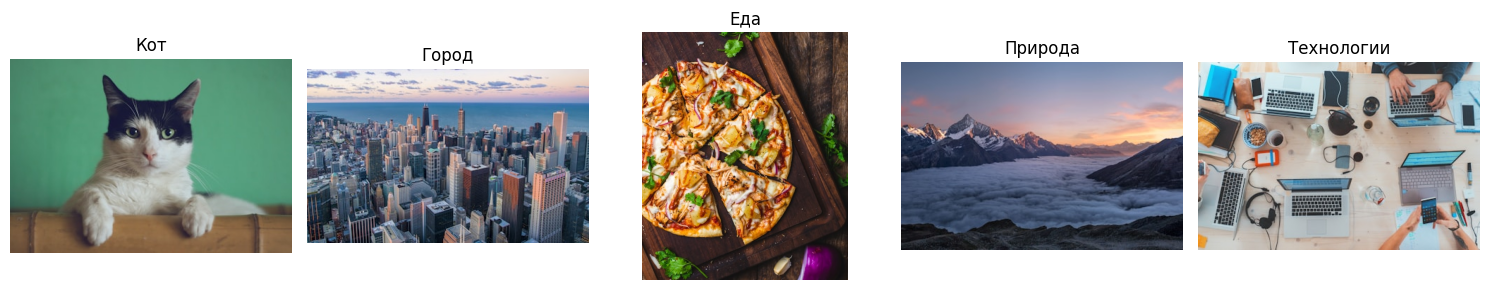

In [5]:
# Визуализация загруженных изображений
fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
if len(images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name.capitalize(), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4.3. Загрузка модели Qwen2.5-VL

Используем **Qwen2.5-VL-3B-Instruct** — современную мультимодальную модель от Alibaba.

**Преимущества:**
- Компактный размер (3B параметров) — помещается в Colab
- Отличная поддержка русского языка
- Высокое качество распознавания текста (OCR)
- Поддержка изображений разного разрешения
- Улучшенное понимание диаграмм и графиков

In [ ]:
# Название модели
# Qwen2.5-VL-3B — современная мультимодальная модель с улучшенным качеством
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

# Альтернатива для слабых GPU:
# model_name = "Qwen/Qwen2-VL-2B-Instruct"  # ~4GB памяти

print(f"Загрузка модели: {model_name}")
print("Это может занять 3-5 минут...")
print(f"\n⚠️ Примечание: Модель занимает ~6GB GPU памяти")

Загрузка модели: Qwen/Qwen2.5-VL-3B-Instruct
Это может занять 3-5 минут...

⚠️ Примечание: Модель занимает ~6GB GPU памяти


In [7]:
# Загрузка процессора и модели
print("Загрузка процессора...")

# Для Qwen2.5-VL используем правильный процессор
processor = AutoProcessor.from_pretrained(
    model_name, 
    trust_remote_code=True,
    use_fast=True  # Быстрый токенизатор
)

print("Загрузка модели (может занять 2-5 минут)...")

# Загрузка модели на GPU
# ВАЖНО: Используем Qwen2_5_VLForConditionalGeneration для Qwen2.5-VL!
if device == "cuda":
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        ignore_mismatched_sizes=True,
        device_map="cuda"  # Явное указание CUDA
    )
else:
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        ignore_mismatched_sizes=True
    )
    model = model.to(device)

print("\n✓ Модель Qwen2.5-VL загружена")
print(f"Параметров: {model.num_parameters():,}")
print(f"Устройство: {model.device}")

Загрузка процессора...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]


✓ Модель Qwen2.5-VL загружена
Параметров: 3,754,622,976
Устройство: cuda:0


### 4.4. Генерация описаний изображений (Captioning)

Создадим функцию для автоматического описания изображений.

In [8]:
# Функция для генерации описания
def generate_caption(image, model, processor, prompt=None):
    """
    Генерация текстового описания изображения.
    
    Args:
        image: PIL Image объект
        model: Загруженная модель
        processor: Процессор для предобработки
        prompt: Промпт для генерации (по умолчанию None)
    
    Returns:
        Сгенерированное описание
    """
    if prompt is None:
        prompt = "Опиши это изображение подробно на русском языке."
    
    # Формирование сообщений для Qwen2.5-VL
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]
    
    # Применение шаблона чата и обработка
    # apply_chat_template сам обрабатывает изображения для Qwen2.5-VL
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
        padding=True
    ).to(device)
    
    # Генерация
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            top_p=0.9,
            do_sample=True
        )
    
    # Декодирование
    response = processor.decode(outputs[0], skip_special_tokens=True)
    
    return response

print("Функция генерации описаний готова")

Функция генерации описаний готова


In [9]:
# Тестирование на всех изображениях
print("="*60)
print("ГЕНЕРАЦИЯ ОПИСАНИЙ ИЗОБРАЖЕНИЙ (Qwen2.5-VL)")
print("="*60)

captions = {}

for name, img in images.items():
    print(f"\n📷 Изображение: {name.upper()}")
    print("-" * 60)
    
    caption = generate_caption(img, model, processor)
    captions[name] = caption
    
    print(f"Описание: {caption}")
    print()

ГЕНЕРАЦИЯ ОПИСАНИЙ ИЗОБРАЖЕНИЙ (Qwen2.5-VL)

📷 Изображение: КОТ
------------------------------------------------------------
Описание: system
You are a helpful assistant.
user
Опиши это изображение подробно на русском языке.
assistant
На изображении изображен белый кот с черными ушами и лапками, лежащий на желтом предмете. Кот выглядит спокойным и расслабленным, смотрит прямо в камеру, показывая свои зеленые глаза и белую шерсть. На заднем плане видна светлая стена, которая создает контраст с черной и белой шерстью кота.


📷 Изображение: ГОРОД
------------------------------------------------------------
Описание: system
You are a helpful assistant.
user
Опиши это изображение подробно на русском языке.
assistant
На этом изображении показано городское пространство, вероятно, Чикаго, основанное на видимых высотных зданиях и городской застройке. 

Видно много небоскребов различных размеров и стилей. Среди них есть как современные, высокие здания с прозрачными стеклянными фасадами, так и бо

### 4.5. Visual Question Answering (VQA)

Зададим вопросы к изображениям.

In [10]:
# Функция для VQA
def visual_qa(image, question, model, processor):
    """
    Ответ на вопрос об изображении.
    
    Args:
        image: PIL Image объект
        question: Вопрос об изображении
        model: Загруженная модель
        processor: Процессор
    
    Returns:
        Ответ модели
    """
    # Формирование сообщений для Qwen2.5-VL
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question}
            ]
        }
    ]
    
    # Применение шаблона чата
    text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    # Обработка входа
    inputs = processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt"
    ).to(device)
    
    # Генерация
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.3,
            do_sample=True
        )
    
    response = processor.decode(outputs[0], skip_special_tokens=True)
    
    return response

print("Функция VQA готова")

Функция VQA готова


In [11]:
# Вопросы для каждого изображения
questions = {
    "кот": [
        "Какого цвета кот?",
        "Где находится кот?",
        "Что делает кот?"
    ],
    "город": [
        "Какие здания видны на изображении?",
        "Какое время суток изображено?",
        "Есть ли на фото люди?"
    ],
    "еда": [
        "Какое блюдо изображено?",
        "Какие ингредиенты можно увидеть?",
        "Это сладкое или солёное блюдо?"
    ],
    "природа": [
        "Какой ландшафт изображён?",
        "Какое время года?",
        "Есть ли вода на изображении?"
    ],
    "технологии": [
        "Какие устройства видны на столе?",
        "Какое освещение в помещении?",
        "Для чего может использоваться это рабочее место?"
    ]
}

print("="*60)
print("VISUAL QUESTION ANSWERING (VQA)")
print("="*60)

for img_name, img_questions in questions.items():
    if img_name not in images:
        continue
    
    print(f"\n📷 Изображение: {img_name.upper()}")
    print("-" * 60)
    
    for q in img_questions:
        answer = visual_qa(images[img_name], q, model, processor)
        print(f"\n  ❓ Вопрос: {q}")
        print(f"  💬 Ответ: {answer}")

VISUAL QUESTION ANSWERING (VQA)

📷 Изображение: КОТ
------------------------------------------------------------

  ❓ Вопрос: Какого цвета кот?
  💬 Ответ: system
You are a helpful assistant.
user
Какого цвета кот?
assistant
Кот в изображении черно-белый.

  ❓ Вопрос: Где находится кот?
  💬 Ответ: system
You are a helpful assistant.
user
Где находится кот?
assistant
Кот находится на верхней части желтого предмета, возможно, это диван или кровать.

  ❓ Вопрос: Что делает кот?
  💬 Ответ: system
You are a helpful assistant.
user
Что делает кот?
assistant
Кот лежит на краю стула, выглядит расслабленным и внимательно смотрит вперед.

📷 Изображение: ГОРОД
------------------------------------------------------------

  ❓ Вопрос: Какие здания видны на изображении?
  💬 Ответ: system
You are a helpful assistant.
user
Какие здания видны на изображении?
assistant
На изображении видны следующие здания:

1. Willis Tower (ранее известный как Sears Tower)
2. John Hancock Center
3. Trump International H

### 4.6. Загрузка модели Qwen2-VL-2B (ОПЦИОНАЛЬНО)

**Примечание:** Этот раздел для продвинутого уровня. Сравним две версии модели.

Сравним Qwen2.5-VL-3B с предыдущей версией Qwen2-VL-2B.

In [12]:
# Название модели для сравнения
blip_model_name = "Qwen/Qwen2-VL-2B-Instruct"

print(f"Загрузка модели для сравнения: {blip_model_name}")
print("Это может занять 2-3 минуты...")
print(f"\n⚠️ Примечание: Модель занимает ~4GB GPU памяти")

Загрузка модели для сравнения: Qwen/Qwen2-VL-2B-Instruct
Это может занять 2-3 минуты...

⚠️ Примечание: Модель занимает ~4GB GPU памяти


In [13]:
# Загрузка процессора и модели
print("Загрузка процессора...")
blip_processor = AutoProcessor.from_pretrained(blip_model_name, trust_remote_code=True)

print("Загрузка модели (может занять 2-3 минут)...")

# Загрузка модели на GPU
if device == "cuda":
    blip_model = Qwen2VLForConditionalGeneration.from_pretrained(
        blip_model_name,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        ignore_mismatched_sizes=True,
        device_map="cuda"
    )
else:
    blip_model = Qwen2VLForConditionalGeneration.from_pretrained(
        blip_model_name,
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        ignore_mismatched_sizes=True
    )
    blip_model = blip_model.to(device)

print("\n✓ Модель Qwen2-VL-2B загружена")
print(f"Параметров: {blip_model.num_parameters():,}")
print(f"Устройство: {blip_model.device}")

Загрузка процессора...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]


✓ Модель Qwen2-VL-2B загружена
Параметров: 2,208,985,600
Устройство: cuda:0


### 4.7. Сравнение Qwen2-VL-2B и Qwen2.5-VL-3B (ОПЦИОНАЛЬНО)

Сравним качество генерации двух версий модели.

In [14]:
# Функция генерации для Qwen2-VL-2B
def qwen2_generate_caption(image, model, processor):
    """Генерация описания для Qwen2-VL-2B"""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Опиши это изображение подробно на русском языке."}
            ]
        }
    ]
    
    text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            do_sample=True
        )
    
    caption = processor.decode(outputs[0], skip_special_tokens=True)
    return caption

print("Функция для Qwen2-VL-2B готова")

Функция для Qwen2-VL-2B готова


СРАВНЕНИЕ МОДЕЛЕЙ на изображении: КОТ

🤖 Qwen2.5-VL-3B (новее, лучше):
------------------------------------------------------------
system
You are a helpful assistant.
user
Опиши это изображение подробно на русском языке.
assistant
На изображении изображен кот, который лежит на верхней части какого-то объекта. Кот имеет чёрно-белую шерсть и смотрит прямо в камеру, его глаза выглядят яркими и живыми. Нос кота розовый, усы длинные и белые. Кот лежит на коричневом или бежевом фоне, который может быть частью мебели или другого предмета. Фон за котом светло-зелёный, что контрастирует с черно-белой шерстью кота. Кот выглядит спокоенным и расслабленным.

🤖 Qwen2-VL-2B (старее, быстрее):
------------------------------------------------------------
system
You are a helpful assistant.
user
Опиши это изображение подробно на русском языке.
assistant
На изображении изображен кот, который сидит на деревянном столе. Кот имеет белую шерсть с черными пятнами и крупные, зеленоватые глаза. Он смотрит впе

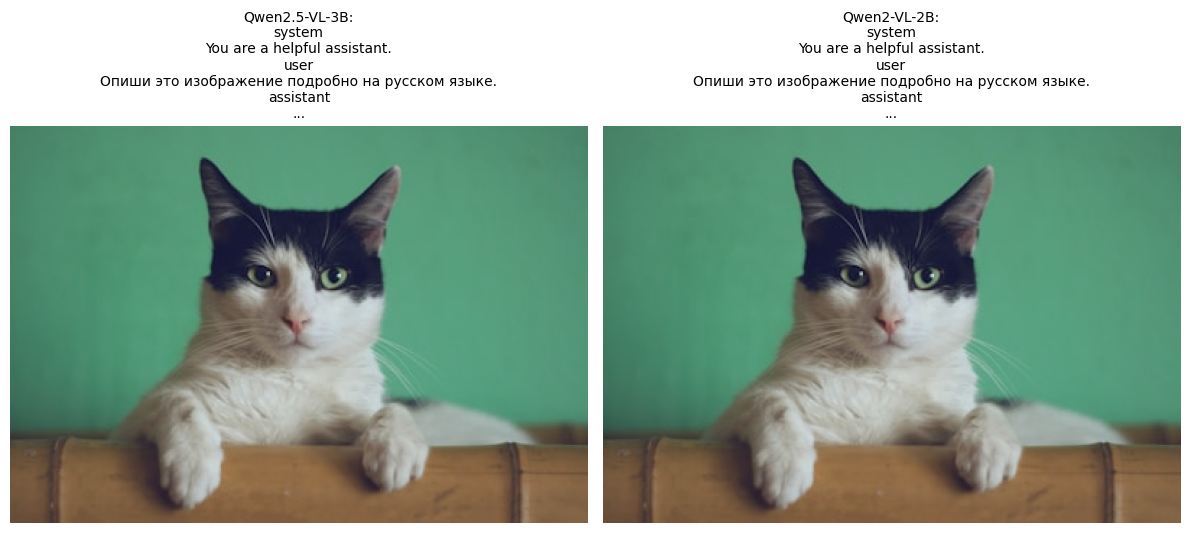

In [15]:
# Сравнение на одном изображении
test_image_name = "кот"
test_image = images.get(test_image_name)

if test_image:
    print("="*60)
    print(f"СРАВНЕНИЕ МОДЕЛЕЙ на изображении: {test_image_name.upper()}")
    print("="*60)
    
    # Qwen2.5-VL-3B
    print("\n🤖 Qwen2.5-VL-3B (новее, лучше):")
    print("-" * 60)
    qwen25_caption = generate_caption(test_image, model, processor)
    print(qwen25_caption)
    
    # Qwen2-VL-2B
    print("\n🤖 Qwen2-VL-2B (старее, быстрее):")
    print("-" * 60)
    qwen2_caption = qwen2_generate_caption(test_image, blip_model, blip_processor)
    print(qwen2_caption)
    
    # Визуализация
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(test_image)
    plt.title(f"Qwen2.5-VL-3B:\n{qwen25_caption[:100]}...", fontsize=10)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(test_image)
    plt.title(f"Qwen2-VL-2B:\n{qwen2_caption[:100]}...", fontsize=10)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Изображение '{test_image_name}' не найдено")

## 5. Контрольные вопросы

**Ответы записывайте в эту ячейку (режим Markdown):**

1. **В чём разница между Qwen2.5-VL и BLIP-2?**
   > Ваш ответ...

2. **Как работает архитектура мультимодальной модели?**
   > Ваш ответ...

3. **Какие задачи решает Visual Question Answering (VQA)?**
   > Ваш ответ...

4. **Почему для мультимодальных моделей требуется больше памяти GPU, чем для текстовых LLM?**
   > Ваш ответ...

5. **Какие ограничения есть у современных мультимодальных моделей?**
   > Ваш ответ...

6. **Какие преимущества у Qwen2.5-VL перед другими мультимодальными моделями?**
   > Ваш ответ...

---

## 6. Полезные ресурсы

- 📚 [LLaVA Documentation](https://llava-vl.github.io/) — официальный сайт проекта
- 📖 [LLaVA Paper](https://arxiv.org/abs/2304.08485) — оригинальная статья
- 📖 [BLIP-2 Paper](https://arxiv.org/abs/2301.12597) — описание BLIP-2
- 🎥 [Multimodal AI Explained](https://www.youtube.com/watch?v=1z25bB8xhs4) — видео-объяснение
- 🔍 [Hugging Face LLaVA](https://huggingface.co/llava-hf) — модели LLaVA на HF
- 🖼️ [Unsplash](https://unsplash.com/) — бесплатные изображения для тестов

---

> **Примечание:** Все лабораторные работы выполняются в Google Colab с использованием бесплатных ресурсов. Сохраняйте копию ноутбука в своём Google Drive через `File → Save a copy in Drive`.